In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('./data/cleaned_fake_real_news.csv')
df.head(5)

,title,text,subject,date,target
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,News,"December 31, 2017",1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,News,"December 31, 2017",1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",News,"December 30, 2017",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",News,"December 29, 2017",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,News,"December 25, 2017",1


In [3]:
df.shape

(44689, 5)

In [4]:
# Drop 'subject' and 'date' columns
df.drop(columns=['subject', 'date'], inplace=True)
df.head(5)

,title,text,target
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,1
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,1
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",1
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",1
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,1


In [5]:
# Create new column
df['news'] = "<title>" + df['title'] + "<content>" + df['text'] + "<end>"

df.head(5)

,title,text,target,news
0,Donald Trump Sends Out Embarrassing New Year’...,Donald Trump just couldn t wish all Americans ...,1,<title> Donald Trump Sends Out Embarrassing Ne...
1,Drunk Bragging Trump Staffer Started Russian ...,House Intelligence Committee Chairman Devin Nu...,1,<title> Drunk Bragging Trump Staffer Started R...
2,Sheriff David Clarke Becomes An Internet Joke...,"On Friday, it was revealed that former Milwauk...",1,<title> Sheriff David Clarke Becomes An Intern...
3,Trump Is So Obsessed He Even Has Obama’s Name...,"On Christmas day, Donald Trump announced that ...",1,<title> Trump Is So Obsessed He Even Has Obama...
4,Pope Francis Just Called Out Donald Trump Dur...,Pope Francis used his annual Christmas Day mes...,1,<title> Pope Francis Just Called Out Donald Tr...


In [6]:
df_model = df[['news', 'target']]
df_model.head(5)

,news,target
0,<title> Donald Trump Sends Out Embarrassing Ne...,1
1,<title> Drunk Bragging Trump Staffer Started R...,1
2,<title> Sheriff David Clarke Becomes An Intern...,1
3,<title> Trump Is So Obsessed He Even Has Obama...,1
4,<title> Pope Francis Just Called Out Donald Tr...,1


In [7]:
import torch

# Check if CUDA is available and set the device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [8]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline

tokenizer = AutoTokenizer.from_pretrained("hamzab/roberta-fake-news-classification")

model = AutoModelForSequenceClassification.from_pretrained("hamzab/roberta-fake-news-classification")

# build a pipeline object to do predictions
pred = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=0,
    max_length=512,
    truncation=True,
    padding=True
)

Device set to use cuda:0


In [9]:
# 4. Run predictions
raw_preds = pred(df_model["news"].tolist())

In [39]:
raw_preds[:10]

[{'label': 'FAKE', 'score': 0.9999794960021973},
 {'label': 'FAKE', 'score': 0.9999686479568481},
 {'label': 'FAKE', 'score': 0.9999804496765137},
 {'label': 'FAKE', 'score': 0.9999799728393555},
 {'label': 'FAKE', 'score': 0.9999169111251831},
 {'label': 'FAKE', 'score': 0.9999804496765137},
 {'label': 'FAKE', 'score': 0.9999790191650391},
 {'label': 'FAKE', 'score': 0.999980092048645},
 {'label': 'FAKE', 'score': 0.9999794960021973},
 {'label': 'FAKE', 'score': 0.9999802112579346}]

In [11]:
label2id = {"FAKE": 1, "TRUE": 0}
id2label = {1: "FAKE", 0: "TRUE"}

In [12]:
# 5. Convert predictions to DataFrame
predicted_labels = [label2id[pred['label']] for pred in raw_preds]
confidences = [pred['score'] for pred in raw_preds]


# Ensure df_model is a copy, not a view
df_model = df_model.copy()

# 6. Add predictions to DataFrame
df_model["predicted_label"] = predicted_labels
df_model["confidence"] = confidences

df_model.head(5)

,news,target,predicted_label,confidence
0,<title> Donald Trump Sends Out Embarrassing Ne...,1,1,0.999979
1,<title> Drunk Bragging Trump Staffer Started R...,1,1,0.999969
2,<title> Sheriff David Clarke Becomes An Intern...,1,1,0.999980
3,<title> Trump Is So Obsessed He Even Has Obama...,1,1,0.999980
4,<title> Pope Francis Just Called Out Donald Tr...,1,1,0.999917


In [13]:
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score

y_true = df_model["target"]
y_pred = df_model["predicted_label"]

# Accuracy
accuracy = accuracy_score(y_true, y_pred)

# Precision, Recall, F1
precision = precision_score(y_true, y_pred)
recall = recall_score(y_true, y_pred)
f1 = f1_score(y_true, y_pred)

# Full classification report
report = classification_report(y_true, y_pred, target_names=["Real", "Fake"])

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1-score:", f1)
print("\nClassification Report:\n", report)

Accuracy: 0.9997762312873414
Precision: 0.999659342531085
Recall: 0.9999148138683023
F1-score: 0.9997870618798177

Classification Report:
               precision    recall  f1-score   support

        Real       1.00      1.00      1.00     21211
        Fake       1.00      1.00      1.00     23478

    accuracy                           1.00     44689
   macro avg       1.00      1.00      1.00     44689
weighted avg       1.00      1.00      1.00     44689



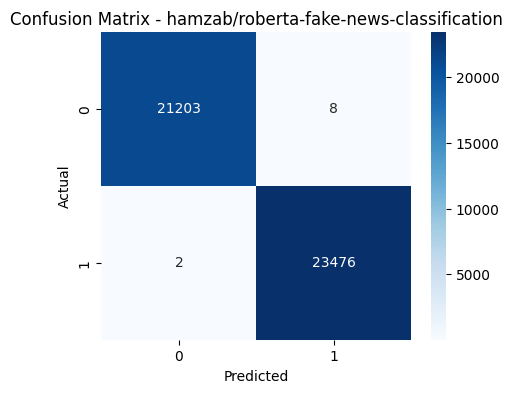

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix  
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title(f"Confusion Matrix - hamzab/roberta-fake-news-classification")
plt.show()

In [14]:
# for explainability with shap
def predict_prob(texts):
    if isinstance(texts, np.ndarray):
        texts = texts.tolist()

    inputs = tokenizer.batch_encode_plus(
        texts,
        max_length=512,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model.to(device)
    inputs = {key: val.to(device) for key, val in inputs.items()}

    with torch.no_grad():
        output = model(**inputs)
        probs = torch.nn.functional.softmax(output.logits, dim=1)

    return probs.cpu().numpy()

In [15]:
import shap

# Use SHAP's TextExplainer for text-based models
explainer = shap.Explainer(predict_prob, tokenizer)

In [28]:
# df_model["news"][40:45].tolist()

In [29]:
# extract few samples for explanation
sample_texts = df_model["news"][40:45].tolist()

# Get SHAP values for the sample texts
shap_values = explainer(sample_texts)

  0%|          | 0/498 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  40%|████████████████████████████████████████████████████████████▊                                                                                           | 2/5 [00:00<?, ?it/s]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer:  80%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████▏                            | 4/5 [00:20<00:03,  3.30s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 5/5 [00:27<00:00,  4.75s/it]

  0%|          | 0/498 [00:00<?, ?it/s]

PartitionExplainer explainer: 6it [00:33,  8.44s/it]                                                                                                                                                             


In [30]:
shap.plots.text(shap_values)

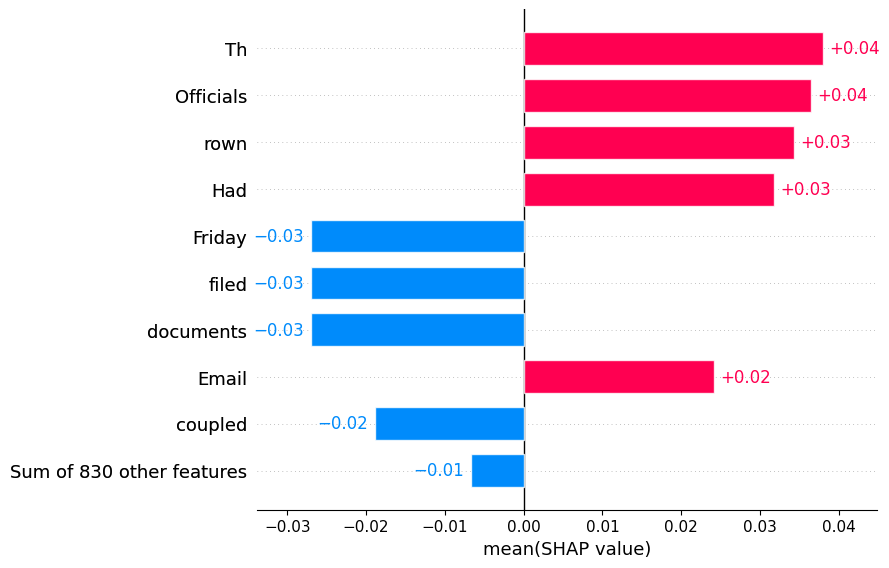

In [37]:
shap.plots.bar(shap_values[:, :, 0].mean(0))

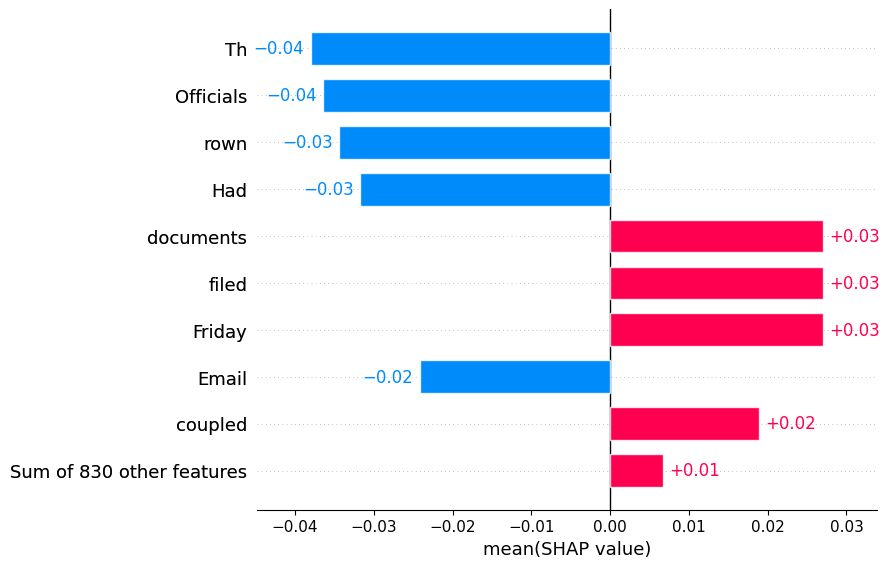

In [38]:
shap.plots.bar(shap_values[:, :, 1].mean(0))

In [41]:
def modelPredict(title, content):
    text = "<title>" + title + "<content>" + content + "<end>"
    result = pred([text])
    print(result)

In [42]:
# buzzfeed fake news content
modelPredict("Proof The Mainstream Media Is Manipulating The Election By Taking Bill Clinton Out Of Context",
             """
             I woke up this morning to find a variation of this headline splashed all over my news feed:

Bill Clinton: â€˜Naturalâ€™ For Foundation Donors to Seek Favors

Hereâ€™s Google:

Naturally, my reaction was â€œoh, s**t, what did Bill Clinton do to damage his wifeâ€™s campaign now?â€

Of course, the headline sounds really, really awful. It plays right into the idea that the Clinton Foundation is all about pay to play, just like Donald Trump has been saying all along. Unfortunately, it takes reading beyond the headlines, which is something most people donâ€™t do, to find out the real story â€“ and the real story is that there is no pay to play.

â€œIt was natural for people whoâ€™ve been our political allies and personal friends to call and ask for things. And I trusted the State Department wouldnâ€™t do anything they shouldnâ€™t do,â€ Clinton told NPR in an interview that aired Monday morning. Source: CNN

In other words, people can ask for favors, but that certainly doesnâ€™t mean theyâ€™ll get them. Leaked emails have shown that some Clinton Foundation donors have gotten meetings with Clinton and that others were turned down. There is zero evidence of pay to play. In other words, people might have asked for favors, but thereâ€™s no evidence they got them.

Now, letâ€™s talk about the foundation the media doesnâ€™t like to mention, the Trump Foundation. Trump hasnâ€™t given to his own foundation since 2008. He does collect money from others, though, and gives it in his name. He also takes from the charity and allegedly buys things like oil paintings and football helmets, all for himself, but out of charity money.

New York Attorney General Eric Schneiderman said in a September 13 CNN interview that his office is investigating Trumpâ€™s charitable foundation over concerns that it â€œengaged in some improprietyâ€ as related to New York charity laws. The investigation launched amid reports from The Washington Post that Trump spent money from his charity on items meant to benefit himself, such as a $20,000 oil painting of himself and a $12,000 autographed football helmet, and also recycled othersâ€™ contributions â€œto make them appear to have come from himâ€ although he â€œhasnâ€™t given to the foundation since 2008.â€ Source: Media Matters

Media Matters goes on to talk about the double standard and about how clearly the mainstream media is trying to promote Trump at the cost of Clintonâ€™s candidacy:

Journalists have been criticized for the â€œdouble standardâ€ in the ways they cover Trump and Democratic presidential nominee Hillary Clinton. Earlier this month, cable news programs devoted 13 times more coverage to Clintonâ€™s pneumonia diagnosis as The Washington Postâ€™s reporting about the Trump Foundation. This week, both the Trump Foundation and Trump Organization stories were given short shrift by the broadcast news programs in favor of coverage of Donald Trumpâ€™s Dr. Oz stunt.

All of this biased coverage is hurting Clinton and helping Trump. Trump has seen major gains over the last few weeks, largely because the media covers every minor Clinton â€œscandalâ€ (if you call getting sick a â€œscandalâ€) while ignoring every scandal in Trumpâ€™s closet, and trust me, there are a lot.

Featured image via Ethan Miller/Getty Images.""")

[{'label': 'FAKE', 'score': 0.9999802112579346}]


In [46]:
# buzzfeed real news content
modelPredict("Megan Rapinoe Punished Over Not Standing For Anthem?",
             """
             U.S. women's soccer star Megan Rapinoe could face disciplinary action if she continues to kneel during the national anthem before games.

Despite an official statement from U.S. Soccer stating that both coaches and players are expected to stand at attention during the national anthem, Rapinoe continued to kneel at the Sept. 18 game against the Netherlands, protesting what she believes to be injustice and oppression in the United States.

Rapinoe first began her protest in solidarity with San Francisco 49ers quarterback Colin Kaepernick, who announced that he will not stand for the anthem as long as there is continued police brutality and racial prejudice in this country. His statements and actions have created a national movement, with athletes like Rapinoe following in his footsteps.

Popular Video This young teenage singer was shocked when Keith Urban invited her on stage at his concert. A few moments later, he made her wildest dreams come true.

Her actions in particular have angered U.S. Soccer, which released a statement saying that her protest goes against everything the organization stands for.

"As part of the privilege to represent your country, we have an expectation that our players and coaches will stand and honor our flag while the national anthem is played," the statement reads in part, according to ESPN.

While she wasn't immediately punished for her protest, ESPN reports that the situation will be re-evaluated if Rapinoe continues to kneel throughout the rest of the season.

During a home game against the Netherlands, Rapinoe was met with some backlash when she refused to stand for the anthem, with one fan yelling, "Stand up!"

Popular Video This young teenage singer was shocked when Keith Urban invited her on stage at his concert. A few moments later, he made her wildest dreams come true:

Nonetheless, Rapinoe has no plans of quitting her protest and is willing to risk suspension in order to make a statement.

"As of now I plan to keep kneeling," she told ESPN. "I'm trying to kind of formulate a better plan and an action step moving forward. But until then, this is how I can help, this is how I can use my voice going forward, and this is how I can be an ally in this space."
             """)

[{'label': 'FAKE', 'score': 0.9999775886535645}]
